In [1]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("XPU available:", torch.xpu.is_available())
print("XPU device count:", torch.xpu.device_count())

if torch.xpu.is_available():
    print("GPU:", torch.xpu.get_device_name(0))

Python: c:\Users\Tejaswini\OneDrive\Desktop\ML\Distracted_driver\.venv\Scripts\python.exe
PyTorch: 2.14.1+xpu
XPU available: True
XPU device count: 1
GPU: Intel(R) Arc(TM) 140V GPU (16GB)


In [2]:
from pathlib import Path

# Dataset location
DATASET_DIR = Path(
    r"C:\Users\Tejaswini\OneDrive\Desktop\ML\imgs\train"
)

# Check that the dataset exists
print("Dataset exists:", DATASET_DIR.exists())
print("Dataset path:", DATASET_DIR)

# Check the 10 class folders
classes = sorted(
    [folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()]
)

print("\nClasses found:", classes)
print("Number of classes:", len(classes))

# Count images in each class
for class_name in classes:
    class_path = DATASET_DIR / class_name
    image_count = len(list(class_path.glob("*.jpg")))
    print(f"{class_name}: {image_count} images")

Dataset exists: True
Dataset path: C:\Users\Tejaswini\OneDrive\Desktop\ML\imgs\train

Classes found: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Number of classes: 10
c0: 2489 images
c1: 2267 images
c2: 2317 images
c3: 2346 images
c4: 2326 images
c5: 2312 images
c6: 2325 images
c7: 2002 images
c8: 1911 images
c9: 2129 images


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# Basic image transformation
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load the complete dataset
full_dataset = datasets.ImageFolder(
    root=str(DATASET_DIR),
    transform=transform
)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)

# Reproducible 80/20 split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

print("\nTraining images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Total images: 22424
Classes: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']

Training images: 17939
Validation images: 4485


In [4]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 561
Validation batches: 141


In [5]:
import torch.nn as nn
from torchvision import models

# Load ImageNet-pretrained ResNet-18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the final layer for our 10 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Use Intel GPU if available, otherwise CPU
if torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

model = model.to(device)

print("Device:", device)
print("Model: ResNet-18")
print("Number of output classes:", 10)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Tejaswini/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Device: xpu
Model: ResNet-18
Number of output classes: 10


In [6]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

# Number of training passes
NUM_EPOCHS = 10

print("Loss function:", criterion)
print("Optimizer: Adam")
print("Learning rate:", 0.0001)
print("Epochs:", NUM_EPOCHS)

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.0001
Epochs: 10


In [7]:
import time

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / total
    val_accuracy = correct / total

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(
            model.state_dict(),
            "../models/person2_resnet18_best.pth"
        )

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

print("\nBest validation accuracy:", best_val_accuracy)

Epoch [1/10] Train Loss: 0.1718 | Train Acc: 0.9538 | Val Loss: 0.0350 | Val Acc: 0.9911 | Time: 325.1s
Epoch [2/10] Train Loss: 0.0117 | Train Acc: 0.9975 | Val Loss: 0.0192 | Val Acc: 0.9958 | Time: 274.4s
Epoch [3/10] Train Loss: 0.0116 | Train Acc: 0.9972 | Val Loss: 0.0322 | Val Acc: 0.9911 | Time: 259.1s
Epoch [4/10] Train Loss: 0.0200 | Train Acc: 0.9951 | Val Loss: 0.0195 | Val Acc: 0.9953 | Time: 272.7s
Epoch [5/10] Train Loss: 0.0111 | Train Acc: 0.9971 | Val Loss: 0.0153 | Val Acc: 0.9967 | Time: 272.2s
Epoch [6/10] Train Loss: 0.0058 | Train Acc: 0.9985 | Val Loss: 0.0257 | Val Acc: 0.9949 | Time: 247.8s
Epoch [7/10] Train Loss: 0.0180 | Train Acc: 0.9949 | Val Loss: 0.0264 | Val Acc: 0.9951 | Time: 245.5s
Epoch [8/10] Train Loss: 0.0065 | Train Acc: 0.9981 | Val Loss: 0.0237 | Val Acc: 0.9940 | Time: 239.3s
Epoch [9/10] Train Loss: 0.0097 | Train Acc: 0.9975 | Val Loss: 0.0153 | Val Acc: 0.9969 | Time: 248.4s
Epoch [10/10] Train Loss: 0.0038 | Train Acc: 0.9993 | Val Loss:

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load the best ResNet-18 checkpoint
best_model_path = "../models/person2_resnet18_best.pth"
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Classification report
report = classification_report(
    all_labels,
    all_predictions,
    target_names=full_dataset.classes,
    digits=4
)

print(report)

# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

              precision    recall  f1-score   support

          c0     0.9958    1.0000    0.9979       479
          c1     0.9958    1.0000    0.9979       469
          c2     0.9957    1.0000    0.9978       462
          c3     1.0000    0.9979    0.9989       473
          c4     1.0000    0.9958    0.9979       477
          c5     1.0000    0.9978    0.9989       448
          c6     0.9979    0.9979    0.9979       484
          c7     1.0000    0.9949    0.9974       392
          c8     0.9973    0.9946    0.9960       372
          c9     0.9930    0.9953    0.9942       429

    accuracy                         0.9975      4485
   macro avg     0.9976    0.9974    0.9975      4485
weighted avg     0.9976    0.9975    0.9975      4485

Confusion Matrix:
[[479   0   0   0   0   0   0   0   0   0]
 [  0 469   0   0   0   0   0   0   0   0]
 [  0   0 462   0   0   0   0   0   0   0]
 [  1   0   0 472   0   0   0   0   0   0]
 [  0   2   0   0 475   0   0   0   0   0]
 [  1   

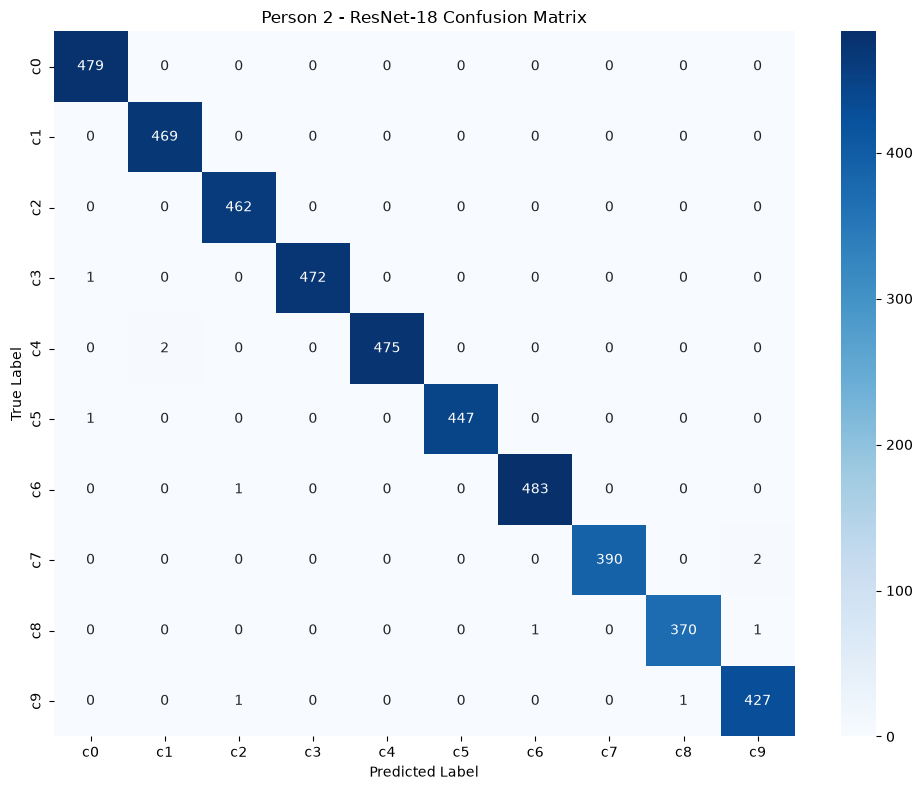

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=full_dataset.classes,
    yticklabels=full_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Person 2 - ResNet-18 Confusion Matrix")
plt.tight_layout()

plt.show()

In [11]:
# Save Person 2 ResNet-18 model

import os

os.makedirs("../models", exist_ok=True)

model_path = "../models/person2_resnet18.pth"

torch.save(model.state_dict(), model_path)

print("Model saved successfully!")
print("Saved to:", model_path)

Model saved successfully!
Saved to: ../models/person2_resnet18.pth


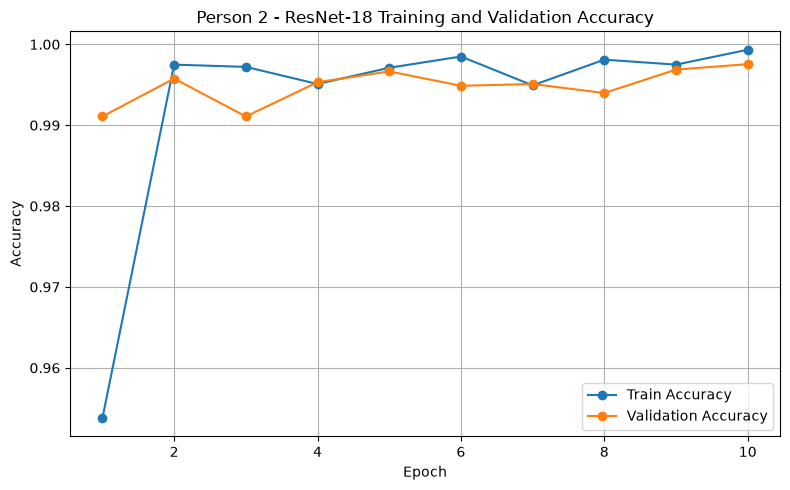

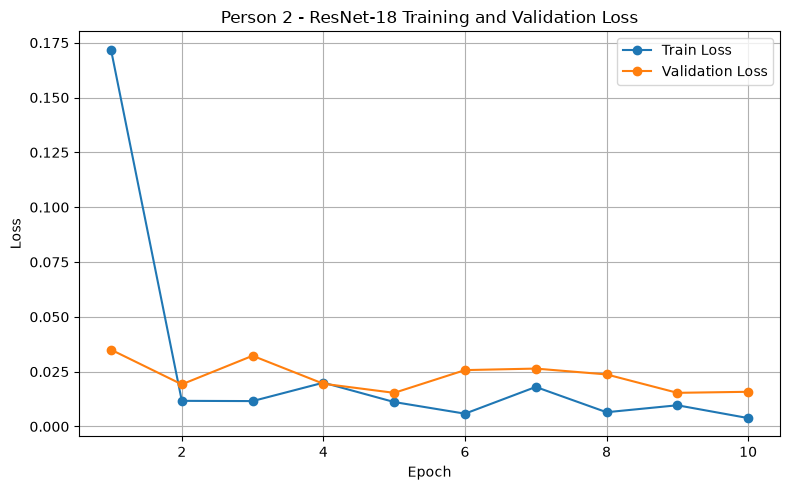

Graphs saved successfully!
../results/plots/person2_training_validation_accuracy.png
../results/plots/person2_training_validation_loss.png


In [12]:
import matplotlib.pyplot as plt

# Create results folder
os.makedirs("../results/plots", exist_ok=True)

epochs = range(1, len(train_losses) + 1)

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Person 2 - ResNet-18 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_path = "../results/plots/person2_training_validation_accuracy.png"
plt.savefig(accuracy_path, dpi=300)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Person 2 - ResNet-18 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_path = "../results/plots/person2_training_validation_loss.png"
plt.savefig(loss_path, dpi=300)
plt.show()

print("Graphs saved successfully!")
print(accuracy_path)
print(loss_path)

In [13]:
# Final comparison: Person 1 CNN vs Person 2 ResNet-18

comparison = {
    "Model": ["Person 1 - CNN", "Person 2 - ResNet-18"],
    "Validation Accuracy": [0.987514, 0.997547],
    "Macro Precision": [0.9875, 0.9976],
    "Macro Recall": [0.9863, 0.9974],
    "Macro F1": [0.9868, 0.9975]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

print("FINAL MODEL COMPARISON")
print("=" * 60)
display(comparison_df)

accuracy_improvement = (
    comparison_df.loc[1, "Validation Accuracy"]
    - comparison_df.loc[0, "Validation Accuracy"]
) * 100

print(f"\nAccuracy improvement: +{accuracy_improvement:.2f} percentage points")

FINAL MODEL COMPARISON


,Model,Validation Accuracy,Macro Precision,Macro Recall,Macro F1
0,Person 1 - CNN,0.987514,0.9875,0.9863,0.9868
1,Person 2 - ResNet-18,0.997547,0.9976,0.9974,0.9975



Accuracy improvement: +1.00 percentage points


## Final Model Comparison

The baseline CNN developed by Person 1 achieved a validation accuracy of 98.75%.

Person 2 improved the approach using transfer learning with an ImageNet-pretrained ResNet-18 model. The ResNet-18 achieved a validation accuracy of 99.75%, giving an improvement of approximately 1.00 percentage point.

The macro F1-score also improved from 98.68% for the baseline CNN to 99.75% for ResNet-18. The improvement was particularly noticeable for the previously difficult Hair & Makeup class (c8), whose recall increased from 93.28% to 99.46%.

These results indicate that transfer learning with ResNet-18 provides better feature extraction and classification performance for the distracted-driver detection task than the baseline CNN.